<h1 style="color:magenta;">NSL - Exercises 11 </h1>

### 21/5/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 11.2

### Polynomial fit

The aim of this exercise is to extend the previous neural network structure to obtain a reasonable fit of the following 3rd-order polynomial function:

$$
f(x)=4-3x-2x^2+3x^3
$$

for $x \in [-1,1]$.

The reasonable choices made for the parameters of the model are:
- **Number of layers and neurons**: one input layer and one output layer made of one neuron each, reflecting the single input ($x$) and output ($y$) of the function. I implemented two hidden layers made of 32 and 16 neurons respectively. This structure helps the network condense the information, and the specific numbers (32 and 16) optimize the computation by reflecting the binary nature of the computer hardware.
- **Activation function**: I chose the `relu` activation function for the hidden layers because its non-linear nature allows the network to bend the space and capture the polynomial's ups and downs. I initially tried using `tanh` unsuccessfully, as it struggled to converge. To allow the network to predict values outside the $[0, +\infty)$ range of the `relu`, the final output layer was left with a default linear activation function, which removes any upper or lower bounds on the final prediction.
- **Optimizer**: I chose the Stochastic Gradient Descent (`sgd`) because it provided a stable convergence, whereas more aggressive optimizers quickly led to overfitting on this specific dataset.
- **Loss function**: I chose the Mean Squared Error (`mse`), which is the standard metric for regression problems.

Looking at the loss evolution, both the training and validation losses smoothly reach a plateau at around 30 epochs without showing any signs of overfitting.

The final plot clearly demonstrates that the neural network possesses an excellent capacity to fit and interpolate the function within the training interval $[-1,1]$. However, it completely fails outside this range, perfectly confirming the expected theoretical behavior: neural networks are powerful tools for interpolation but generally fail when requested to extrapolate outside their training domain.

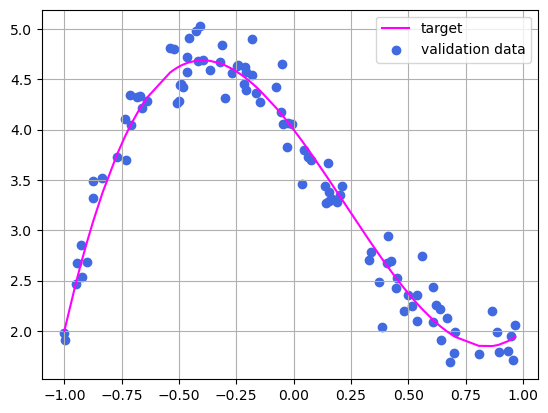

In [1]:
#parameters f(x) = a + b*x + c*x^2 + d*x^3
a = 4 
b = -3
c = -2
d = 3

#training data = 500, noise sigma = 0.1

import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 2000)
x_valid = np.random.uniform(-1, 1, 100)
x_valid.sort()
y_target = a + b*x_valid + c*x_valid*x_valid + d*x_valid*x_valid*x_valid # ideal (target) function

sigma = 0.2 # noise standard deviation
y_train = np.random.normal(a + b*x_train + c*x_train*x_train + d*x_train*x_train*x_train, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(a + b*x_valid + c*x_valid*x_valid + d*x_valid*x_valid*x_valid, sigma)

# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target', color='magenta')
plt.scatter(x_valid, y_valid, color='royalblue', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

In [116]:
# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Input(shape=(1,)))
#hidden layers
model.add(Dense(32, input_shape=(1,), activation='relu'))
model.add(Dense(16, activation='relu'))
#output layers
model.add(Dense(1))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

# get a summary of our composed model
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

In [117]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=30,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.8997 - mse: 2.8997 - val_loss: 0.5593 - val_mse: 0.5593
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4232 - mse: 0.4232 - val_loss: 0.4296 - val_mse: 0.4296
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3368 - mse: 0.3368 - val_loss: 0.3514 - val_mse: 0.3514
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2754 - mse: 0.2754 - val_loss: 0.2904 - val_mse: 0.2904
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2272 - mse: 0.2272 - val_loss: 0.2393 - val_mse: 0.2393
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1838 - mse: 0.1838 - val_loss: 0.1940 - val_mse: 0.1940
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1489 - mse: 0.1489 - val_loss: 0.1579 - val_mse: 0.1579
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1229 - mse: 0.1229 - val_loss: 0.1329 - val_mse: 0.1329
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1040 - mse: 

In [118]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0513 - mse: 0.0513 

Test loss: 0.05132529139518738
Test accuracy: 0.05132529139518738


In [119]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0086 - mse: 0.0086 

Test loss: 0.00864439643919468
Test accuracy: 0.00864439643919468


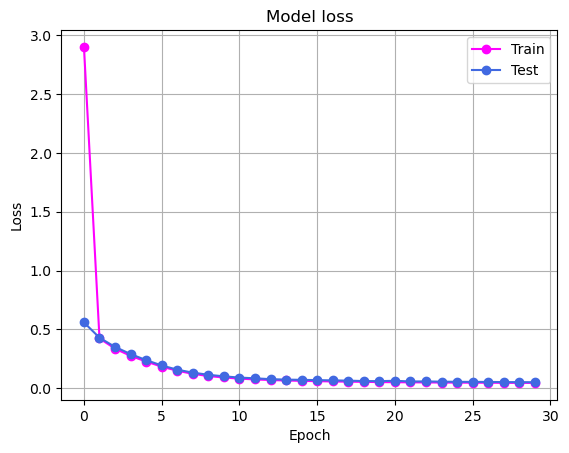

In [120]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'], 'o-', color = 'magenta')
plt.plot(history.history['val_loss'], 'o-', color = 'royalblue')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


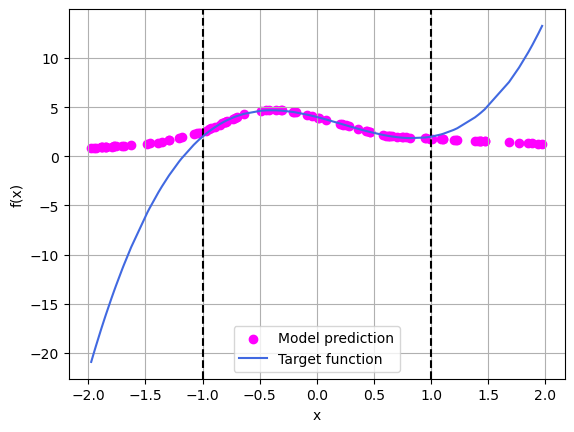

In [121]:
x_predicted = np.random.uniform(-2, 2, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted, color='magenta', label= "Model prediction")
plt.axvline(1., color = 'black', linestyle = '--')
plt.axvline(-1., color = 'black', linestyle = '--')
x_predicted.sort()
y_function = 4 - 3 *  x_predicted - 2 *  x_predicted *  x_predicted + 3 *  x_predicted *  x_predicted * x_predicted 
plt.plot(x_predicted, y_function, color='royalblue',label="Target function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()